In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

In [3]:
TRAIN_CSV_PATH = "occlusion_datasets/train.csv"
TEST_CSV_PATH = "occlusion_datasets/test_students.csv"
IMAGE_ROOT_DIR = "occlusion_datasets/Crop_224_5fp_100K"

train_df = pd.read_csv(TRAIN_CSV_PATH)
test_df = pd.read_csv(TEST_CSV_PATH)

train_df.rename(columns={'filename': 'image_path', 'FaceOcclusion': 'occlusion_score'}, inplace=True)
test_df.rename(columns={'filename': 'image_path'}, inplace=True)

print(f"Nombre de lignes dans le set d'entraînement : {len(train_df)}")
print(f"Nombre de lignes dans le set de test : {len(test_df)}")

display(train_df.head())

Nombre de lignes dans le set d'entraînement : 100000
Nombre de lignes dans le set de test : 29980


,image_path,occlusion_score,gender
0,database3/database3/m.01w0zk1/66-FaceId-0_alig...,0.024005,1.0
1,database3/database3/m.016ywr/88-FaceId-0_align...,0.030028,1.0
2,database3/database3/m.02dfmb/105-FaceId-0_alig...,0.009984,0.0
3,database3/database3/m.01_h_s/33-FaceId-5_align...,0.255016,1.0
4,database3/database3/m.02lqkv/85-FaceId-0_align...,0.252091,1.0


/var/folders/b6/fnjlm2tn6v195s9dwy3mc64h0000gn/T/ipykernel_7892/3739526498.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='gender', ax=axes[0], palette='Set2')


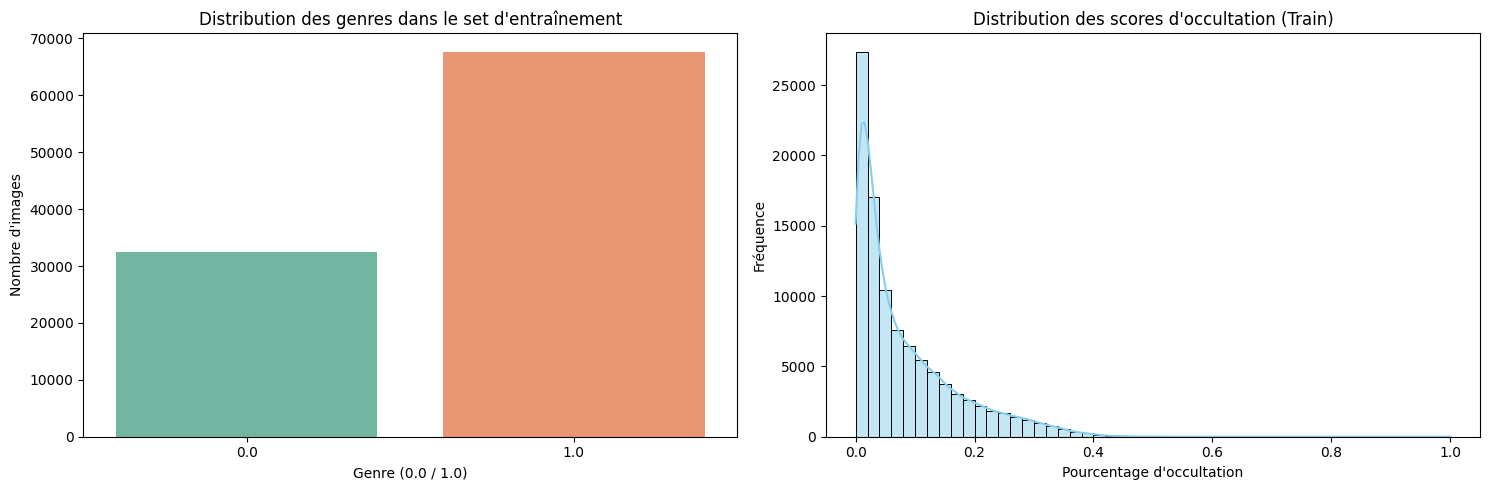

Statistiques des scores d'occultation :


count    100000.000000
mean          0.082720
std           0.086538
min           0.000000
25%           0.017928
50%           0.049661
75%           0.122675
max           1.000000
Name: occlusion_score, dtype: float64

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribution des genres
sns.countplot(data=train_df, x='gender', ax=axes[0], palette='Set2')
axes[0].set_title('Distribution des genres dans le set d\'entraînement')
axes[0].set_xlabel('Genre (0.0 / 1.0)')
axes[0].set_ylabel('Nombre d\'images')

# Distribution des scores d'occultation
sns.histplot(data=train_df, x='occlusion_score', bins=50, kde=True, ax=axes[1], color='skyblue')
axes[1].set_title('Distribution des scores d\'occultation (Train)')
axes[1].set_xlabel('Pourcentage d\'occultation')
axes[1].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

# Statistiques descriptives de l'occultation
print("Statistiques des scores d'occultation :")
display(train_df['occlusion_score'].describe())

/var/folders/b6/fnjlm2tn6v195s9dwy3mc64h0000gn/T/ipykernel_7892/1038093542.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='gender', y='occlusion_score', palette='Set2')


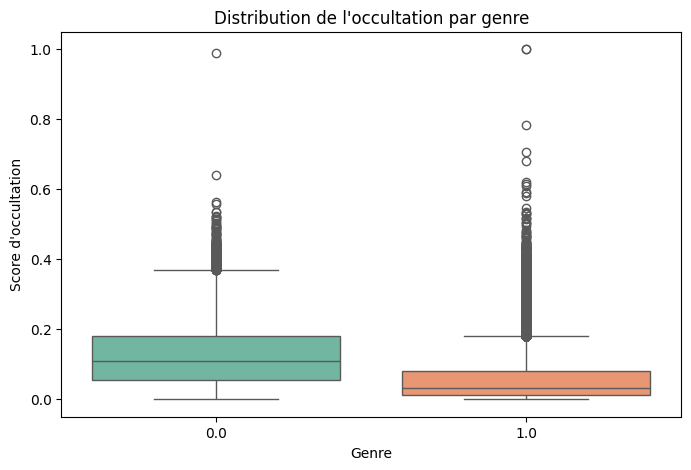

In [5]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=train_df, x='gender', y='occlusion_score', palette='Set2')
plt.title('Distribution de l\'occultation par genre')
plt.xlabel('Genre')
plt.ylabel('Score d\'occultation')
plt.show()

In [6]:
def check_missing_files(df, root_dir):
    missing_files = []
    for path in df['image_path']:
        full_path = os.path.join(root_dir, path)
        if not os.path.isfile(full_path):
            missing_files.append(full_path)
    return missing_files

# Vérification pour le train
missing_train = check_missing_files(train_df, IMAGE_ROOT_DIR)
print(f"Images d'entraînement manquantes sur le disque : {len(missing_train)} / {len(train_df)}")

# Vérification pour le test
missing_test = check_missing_files(test_df, IMAGE_ROOT_DIR)
print(f"Images de test manquantes sur le disque : {len(missing_test)} / {len(test_df)}")

# Si des fichiers manquent, affichage des premiers exemples
if len(missing_train) > 0:
    print("\nExemples de chemins introuvables (Train) :")
    print(missing_train[:5])

Images d'entraînement manquantes sur le disque : 0 / 100000
Images de test manquantes sur le disque : 0 / 29980
